In [1]:
# import classy module
from classy import Class

In [2]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
import numpy as np
#from plotting_utils import plot_segments

fonsize = 14

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=True)
rc('font', family='serif', size=fonsize)

rcParams.update({
    'font.size': fonsize,
    'axes.titlesize': fonsize,
    'axes.labelsize': fonsize,
    'xtick.labelsize': fonsize,
    'ytick.labelsize': fonsize,
    'legend.fontsize': fonsize,
})

## Model parameter and argument definitions

In [3]:
#
# Louis old setup
#  # create instance of the class "Class"
# LambdaCDM = Class()
# # pass input parameters
# # LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
# LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
# LambdaCDM.set({'output':'tCl,pCl,lCl,mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0, 'nowiggle_pk_species':'total'})

# # run class
# LambdaCDM.compute()

# # get reduced Hubble for conversions to 1/Mpc
# h = LambdaCDM.h()

# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'tCl, pCl, lCl, mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})



# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()

In [4]:
# Read data:
dir = '/Users/fynn/PhD/02-Research/01-Coding/class-bispectrum-png-fynn1410/notebooks/test_PNG_implementation/B_tree_without_AP.npz'

data = np.load(dir)

n_triag      = data["n_triag"]
k1_arr       = data["k1_arr"]
k2_arr       = data["k2_arr"]
k3_arr       = data["k3_arr"]
B0           = data["B0"]
B2           = data["B2"]
B4           = data["B4"]
b1           = np.array([ data["b1"] ])
b2           = np.array([ data["b2"] ])
bG2          = np.array([ data["bG2"] ])
s1           = 1 + 2 * np.array([ data["s1"] ])     # NOTE: conversion from 2(1+s1) to 1+s1
s2           = np.array([ data["s3"] ])             # NOTE: Louis switches s2 and s3
s3           = np.array([ data["s2"] ])             # NOTE: Louis switches s2 and s3
P_eps        = np.array([ data["P_eps"] ])
z            = np.array([ data["z"] ])
use_IR_resum = data["use_IR_resum"]


n_z = len(z)

# Additional parameters
q_orth = np.ones(n_z, dtype=np.float64)
q_parr = np.ones(n_z, dtype=np.float64)
AP     = 1/(q_parr * q_orth**2)

# set nonlinear scale for FoG damping
k_nonlinear = 1. # in 1/Mpc
c1_FoG = np.array([ 0. ])

# Set PNG parameters further down

print('b1 =', b1)
print('b2 =', b2)
print('bG2 =', bG2)
print('s1 =', s1)
print('s2 =', s2)
print('s3 =', s3)
print('P_eps =', P_eps)

print(f"n_triag = {n_triag}, z = {z}, use_IR_resum = {use_IR_resum}")
print(f"k1_arr shape: {k1_arr.shape}, B0 shape: {B0.shape}")


b1 = [1.5]
b2 = [-1.]
bG2 = [-0.35]
s1 = [0.]
s2 = [0.]
s3 = [0.]
P_eps = [4199.38827632]
n_triag = [   0    1    2 ... 4997 4998 4999], z = [0.95], use_IR_resum = 1
k1_arr shape: (5000,), B0 shape: (5000,)


In [5]:
# # Make the AP factors
# D_A_fid = 1663.9307801326001
# H_fid = 0.00037966933846752485

# h = LambdaCDM.h()
# H = np.zeros(n_z, 'float64')
# D_A = np.zeros(n_z, 'float64')
# for i in range(n_z):
#     D_A[i] = LambdaCDM.angular_distance(z[i]) # in Mpc
#     H[i]   = LambdaCDM.Hubble(z[i])           # in (Mpc)^(-1)

# #Alcock Pacinsky effect
# q_orth = D_A/D_A_fid  # 1/f_orth  # alpha_perp
# q_parr = H_fid/H                  # alpha_parallel

# print(q_orth, q_parr)

# q_orth = np.ones(n_z, dtype=np.float64)
# q_parr = np.ones(n_z, dtype=np.float64)


## Comparison between this code and Fynn's old code (no AP, no FoG, no fnl)

In [6]:
import time as t
t_start = t.perf_counter()


triangles = np.ascontiguousarray(np.column_stack([k1_arr, k2_arr, k3_arr]), dtype=np.float64)

# Set PNG parameter
bphi = np.array([1.])
bphidelta = np.array([0.])
fnl = 100.
fnl0 = 0. # as reference value
l_max = 4

B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                          b1,
                                                                          b2,
                                                                          bG2,
                                                                          s1,
                                                                          s2,
                                                                          s3,
                                                                          P_eps,
                                                                          c1_FoG,
                                                                          k_nonlinear,
                                                                          bphi,
                                                                          bphidelta,
                                                                          fnl0,
                                                                          triangles,
                                                                          z,
                                                                          l_max,
                                                                          q_orth,
                                                                          q_parr,
                                                                          AP
)
t_end = t.perf_counter()
print(t_end-t_start)

0.0932415840215981


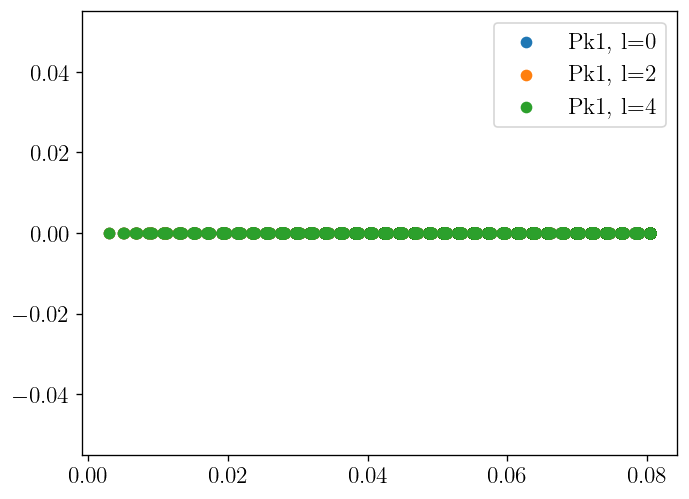

In [7]:


for i in range(3):
    plt.scatter(k1_arr, alpha_k[i,:], label='Pk1, l={}'.format(2*i))
plt.legend()


residual max deviation: 0.002%
residual max deviation: 0.009%
residual max deviation: 0.056%


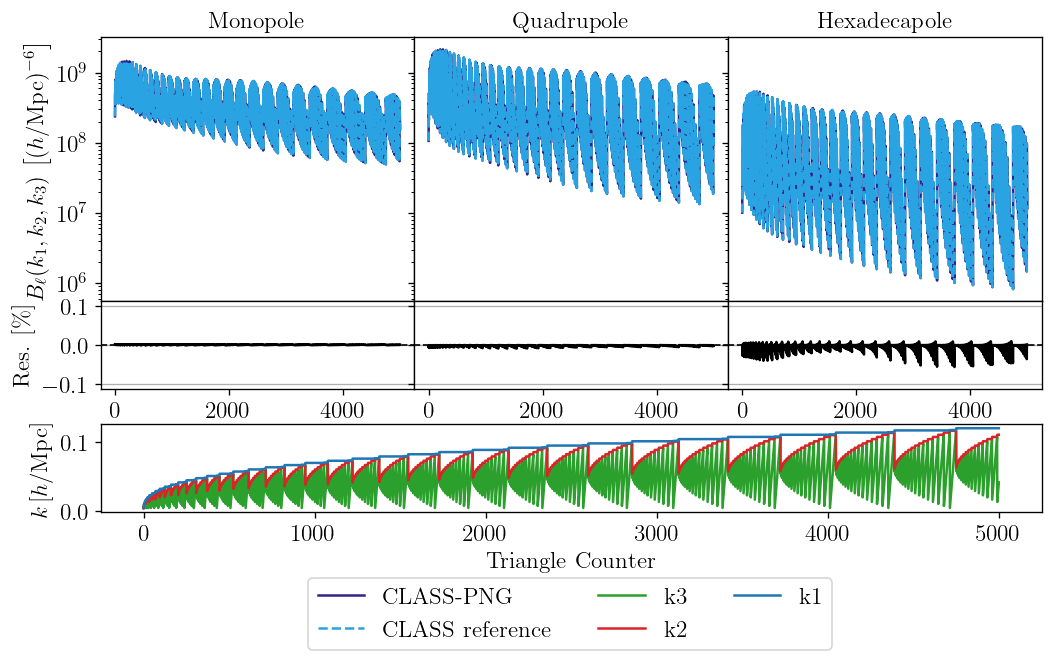

In [8]:
from test_PNG_implementation.python_tools.plotting import plot_comparison, plot_multipoles

model1_label = 'CLASS-PNG'
model2_label = 'CLASS reference'

iz = 0
l0, l2, l4 = 0, 1, 2
plot_comparison(n_triag,
                B_l[iz, l0, :], B0,
                B_l[iz, l2, :], B2,
                B_l[iz, l4, :], B4,
                k1_arr, k2_arr, k3_arr,
                h,
                model1_label,
                model2_label)

# Equilateral Configuration

In [9]:
# plot equilateral triangles
k1_eq = np.logspace(-3, -1, len(n_triag))
k2_eq = k1_eq
k3_eq = k1_eq
n_triag_eq = np.arange(len(k1_eq))

triangles = np.ascontiguousarray(np.column_stack([k1_eq, k2_eq, k3_eq]), dtype=np.float64)


B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                    b1,
                                                                                    b2,
                                                                                    bG2,
                                                                                    s1,
                                                                                    s2,
                                                                                    s3,
                                                                                    P_eps,
                                                                                    c1_FoG,
                                                                                    k_nonlinear,
                                                                                    bphi,
                                                                                    bphidelta,
                                                                                    fnl,
                                                                                    triangles,
                                                                                    z,
                                                                                    l_max,
                                                                                    q_orth,
                                                                                    q_parr,
                                                                                    AP
)

B_l_fnl0, derivs_fnl0, alpha_k_fnl0 = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                                b1,
                                                                                                b2,
                                                                                                bG2,
                                                                                                s1,
                                                                                                s2,
                                                                                                s3,
                                                                                                P_eps,
                                                                                                c1_FoG,
                                                                                                k_nonlinear,
                                                                                                bphi,
                                                                                                bphidelta,
                                                                                                fnl0,
                                                                                                triangles,
                                                                                                z,
                                                                                                l_max,
                                                                                                q_orth,
                                                                                                q_parr,
                                                                                                AP
)
t_end = t.perf_counter()
print(t_end-t_start)


0.8251290840562433


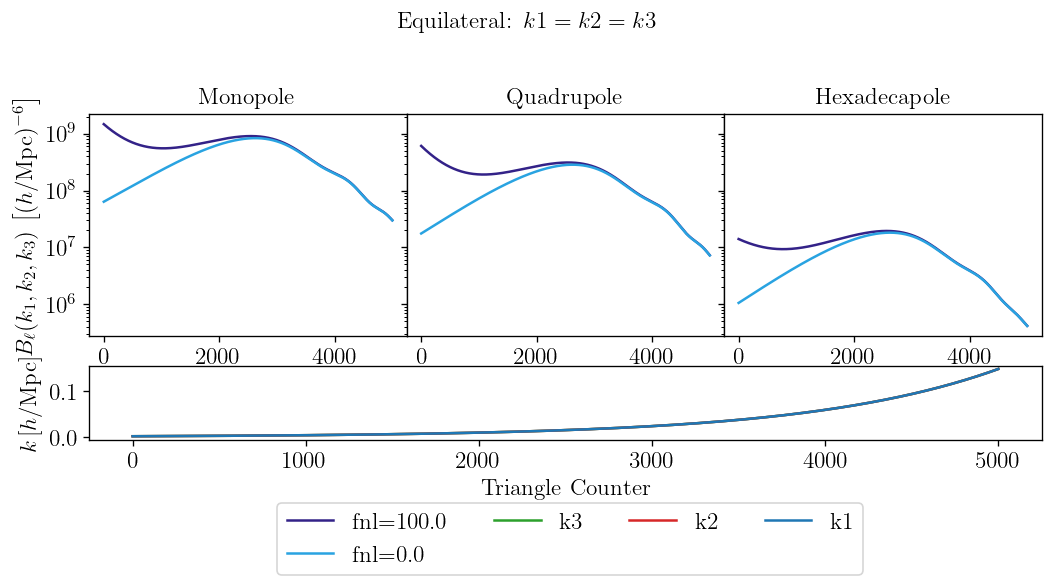

In [10]:
B0 = [ B_l[iz, l0, :], B_l_fnl0[iz, l0, :]]
B2 = [ B_l[iz, l2, :], B_l_fnl0[iz, l2, :]]
B4 = [ B_l[iz, l4, :], B_l_fnl0[iz, l4, :]]

labels = [f'fnl={fnl}', f'fnl={fnl0}']
global_title = 'Equilateral: $k1=k2=k3$'

plot_multipoles(n_triag_eq,
                B0, B2, B4,
                k1_eq, k2_eq, k3_eq,
                h,
                labels, 
                global_title)

# Squeezed Configuration

In [11]:
# plot equilateral triangles
k1_sq = np.logspace(-3, -1, len(n_triag))
k2_sq = k1_sq
k3_sq = 0.05 * k1_sq
n_triag_sq = np.arange(len(k1_sq))

triangles = np.ascontiguousarray(np.column_stack([k1_sq, k2_sq, k3_sq]), dtype=np.float64)

B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                    b1,
                                                                                    b2,
                                                                                    bG2,
                                                                                    s1,
                                                                                    s2,
                                                                                    s3,
                                                                                    P_eps,
                                                                                    c1_FoG,
                                                                                    k_nonlinear,
                                                                                    bphi,
                                                                                    bphidelta,
                                                                                    fnl,
                                                                                    triangles,
                                                                                    z,
                                                                                    l_max,
                                                                                    q_orth,
                                                                                    q_parr,
                                                                                    AP
)

B_l_fnl0, derivs_fnl0, alpha_k_fnl0 = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                                b1,
                                                                                                b2,
                                                                                                bG2,
                                                                                                s1,
                                                                                                s2,
                                                                                                s3,
                                                                                                P_eps,
                                                                                                c1_FoG,
                                                                                                k_nonlinear,
                                                                                                bphi,
                                                                                                bphidelta,
                                                                                                fnl0,
                                                                                                triangles,
                                                                                                z,
                                                                                                l_max,
                                                                                                q_orth,
                                                                                                q_parr,
                                                                                                AP
)
t_end = t.perf_counter()
print(t_end-t_start)


1.2986800000071526


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/ff/6cytkh094g35kn8sx9zksh8h0000gn/T/ipykernel_79055/3920842671.py:6: SyntaxWarning: invalid escape sequence '\c'
  global_title = 'Squeezed: $k1=k2=20 \cdot k3$'


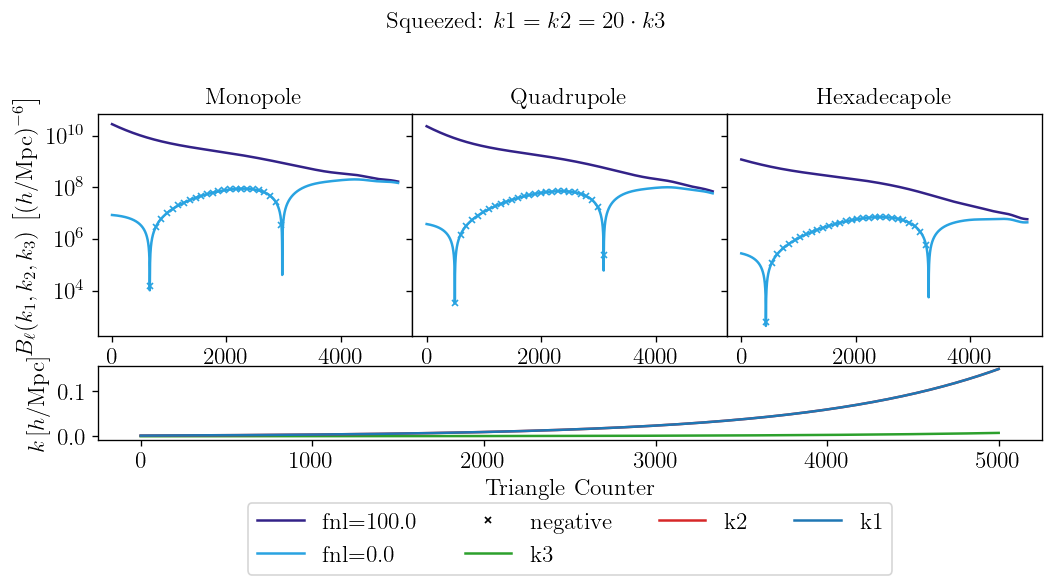

In [12]:
B0 = [ B_l[iz, l0, :], B_l_fnl0[iz, l0, :]]
B2 = [ B_l[iz, l2, :], B_l_fnl0[iz, l2, :]]
B4 = [ B_l[iz, l4, :], B_l_fnl0[iz, l4, :]]

labels = [f'fnl={fnl}', f'fnl={fnl0}']
global_title = 'Squeezed: $k1=k2=20 \cdot k3$'


plot_multipoles(n_triag_sq,
                B0, B2, B4,
                k1_sq, k2_sq, k3_sq,
                h,
                labels,
                global_title)

# Isoscelese

In [13]:
# plot equilateral triangles
k1_iso = np.logspace(-3, -1, len(n_triag))
k2_iso = k1_iso
k3_iso = 0.5 * k1_iso
n_triag_iso = np.arange(len(k1_iso))

triangles = np.ascontiguousarray(np.column_stack([k1_iso, k2_iso, k3_iso]), dtype=np.float64)


B_l, derivs, alpha_k = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                    b1,
                                                                                    b2,
                                                                                    bG2,
                                                                                    s1,
                                                                                    s2,
                                                                                    s3,
                                                                                    P_eps,
                                                                                    c1_FoG,
                                                                                    k_nonlinear,
                                                                                    bphi,
                                                                                    bphidelta,
                                                                                    fnl,
                                                                                    triangles,
                                                                                    z,
                                                                                    l_max,
                                                                                    q_orth,
                                                                                    q_parr,
                                                                                    AP
)

B_l_fnl0, derivs_fnl0, alpha_k_fnl0 = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                                                b1,
                                                                                                b2,
                                                                                                bG2,
                                                                                                s1,
                                                                                                s2,
                                                                                                s3,
                                                                                                P_eps,
                                                                                                c1_FoG,
                                                                                                k_nonlinear,
                                                                                                bphi,
                                                                                                bphidelta,
                                                                                                fnl0,
                                                                                                triangles,
                                                                                                z,
                                                                                                l_max,
                                                                                                q_orth,
                                                                                                q_parr,
                                                                                                AP
)
t_end = t.perf_counter()
print(t_end-t_start)


1.6653024591505527


<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
/var/folders/ff/6cytkh094g35kn8sx9zksh8h0000gn/T/ipykernel_79055/545469227.py:6: SyntaxWarning: invalid escape sequence '\c'
  global_title = 'Isosceles: $k1=k2=2 \cdot k3$'


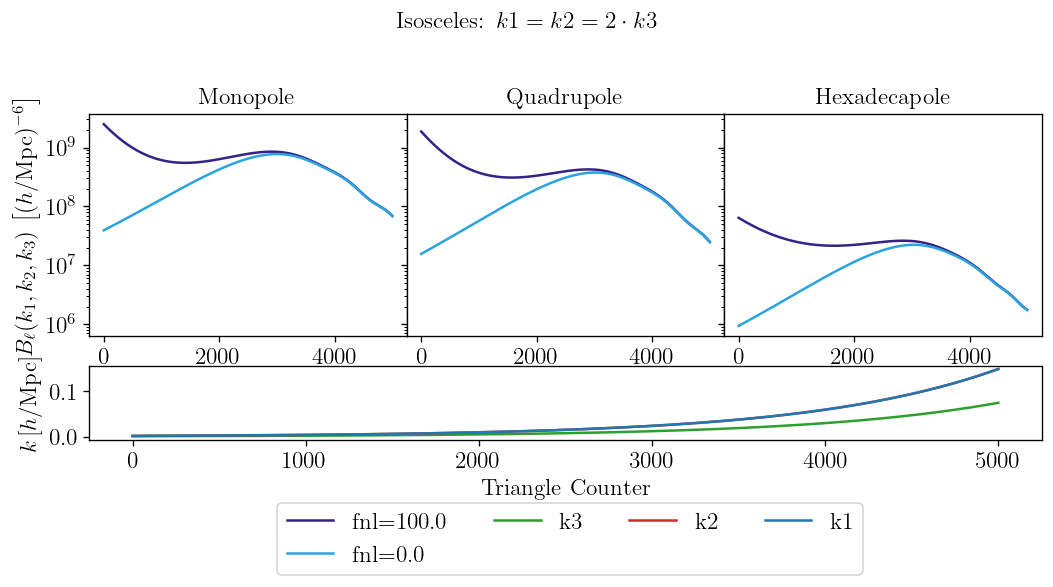

In [14]:
B0 = [ B_l[iz, l0, :], B_l_fnl0[iz, l0, :]]
B2 = [ B_l[iz, l2, :], B_l_fnl0[iz, l2, :]]
B4 = [ B_l[iz, l4, :], B_l_fnl0[iz, l4, :]]

labels = [f'fnl={fnl}', f'fnl={fnl0}']
global_title = 'Isosceles: $k1=k2=2 \cdot k3$'

plot_multipoles(n_triag_iso,
                B0, B2, B4,
                k1_iso, k2_iso, k3_iso,
                h,
                labels,
                global_title)

B_l.shape (1, 3, 5000)
triangles.shape (5000, 3)


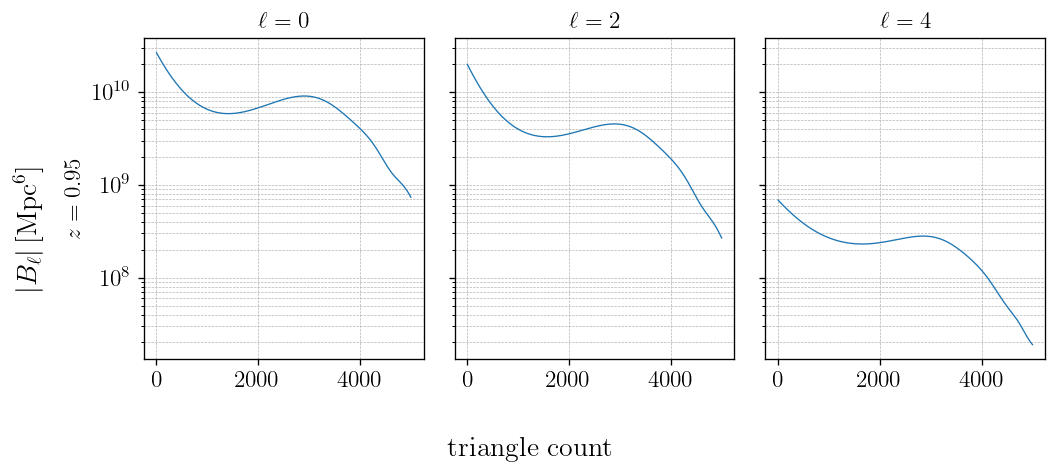

In [15]:
print('B_l.shape', B_l.shape)
print('triangles.shape', triangles.shape)
n_l = B_l.shape[1]
ells = [2*l for l in range(n_l)]
tri_idx = np.arange(triangles.shape[0])

fig, axes = plt.subplots(
    n_z, n_l,
    figsize=(3*n_l, 4*n_z),
    sharex=True,
    sharey=True,
    squeeze=False
)

for zi in range(n_z):
    for li in range(n_l):
        ax = axes[zi, li]

        ax.plot(tri_idx, np.abs(B_l[zi, li, :]), lw=0.8)
        ax.set_yscale('log')
        ax.grid(True, which='both', ls='--', lw=0.4)

        # Column titles: multipoles
        if zi == 0:
            ax.set_title(rf'$\ell={ells[li]}$')

        # Row labels: redshift
        if li == 0:
            ax.text(
                -0.25, 0.5,
                rf'$z={z[zi]}$',
                transform=ax.transAxes,
                rotation=90,
                va='center',
                ha='center'
            )

fig.supxlabel('triangle count')
fig.supylabel(rf'$|B_\ell|\,[\mathrm{{Mpc}}^6]$')

plt.tight_layout()
plt.show()

B_ell = {'B_ell': B_l, 'triangles': triangles, 'z': z, 'ells': ells}

# np.savez('/Users/fynn/PhD/02-Research/01-Coding/class-bispectrum-png-fynn1410/notebooks/test_PNG_implementation/baseline_B_ell.npz',
#         B_ell)



In [16]:
B_l_Fynn = np.zeros((n_z, 3, triangles.shape[0]), dtype=np.float64)

t_start_Fynn = t.perf_counter()
for zi in range(n_z):
    for i in range(triangles.shape[0]):
        for l in range(3):
            ell = 2*l

            B_l_Fynn[zi, l, i] = LambdaCDM.bk_lin_multipoles(1,
                                                             b1[zi],
                                                             b2[zi],
                                                             bG2[zi],
                                                             d1[zi],
                                                             d2[zi],
                                                             d3[zi],
                                                             P_eps[zi],
                                                             c1_FoG[zi],
                                                             triangles[i,0],
                                                             triangles[i,1],
                                                             triangles[i,2],
                                                             ell,
                                                             z[zi])
            
t_end_Fynn = t.perf_counter()
            
# for zi in range(n_z):
#     for i in range(triangles.shape[0]):
#         B_l_Fynn[zi, 0, i] = LambdaCDM.bk_lin_multipoles(1,
#                                                          b1[zi],
#                                                          b2[zi],
#                                                          bG2[zi],
#                                                          d1[zi],
#                                                          d2[zi],
#                                                          d3[zi],
#                                                          P_eps[zi],
#                                                          c1_FoG[zi],
#                                                          triangles[i,0],
#                                                          triangles[i,1],
#                                                          triangles[i,2],
#                                                          0,
#                                                          z[zi])

print(t_end_Fynn-t_start_Fynn)

AttributeError: 'classy.Class' object has no attribute 'bk_lin_multipoles'

True


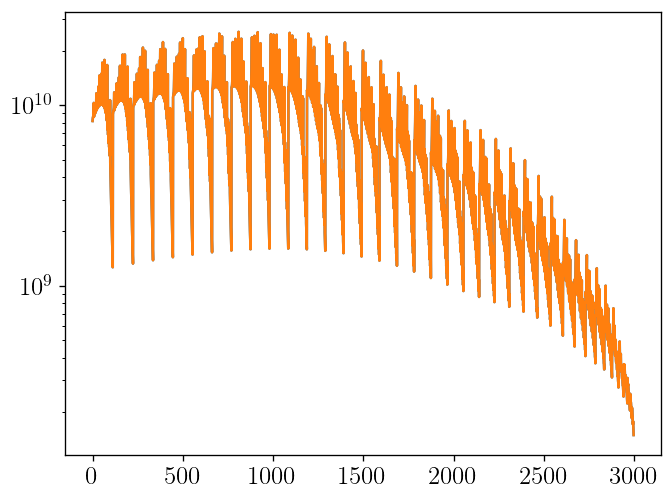

In [ ]:
print(np.array_equal(B_l, B_l_Fynn))

plt.plot(B_l[0,0,:])
plt.plot(B_l_Fynn[0,0,:])
plt.yscale("log")
plt.show()

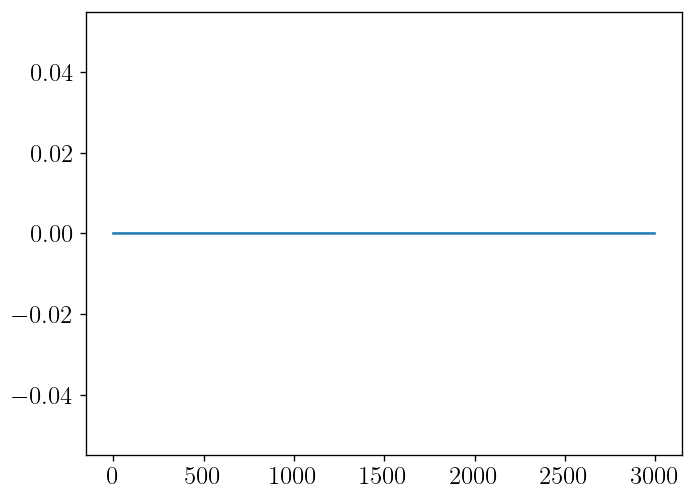

In [ ]:
plt.plot(np.abs((B_l[0,0,:]-B_l_Fynn[0,0,:])/B_l_Fynn[0,0,:]))
plt.show()

## Computation Time Bottleneck

### Timing with power spectra outside of for loop:

0.85 seconds

### Timing with power spectra inside of for loop:

0.65 seconds (1D interpolation)

### Timing for Mono + Quadrupole for array_interpolate_spline and 3000 triangles

0.48 seconds

### Timing for Mono + Quadrupole for array_interpolate_spline_growing_closeby and 3000 triangles

0.39 seconds

### Timing for Mono + Quadrupole for array_interpolate_spline_growing_hunt and 3000 triangles

0.37 seconds

### Checking of derivative implementation is correct

In [ ]:
d_0 = np.array([0.])

B_l, derivs_C = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                            b1,
                                                                            b2,
                                                                            bG2,
                                                                            d1,
                                                                            d2,
                                                                            d3,
                                                                            P_eps,
                                                                            c1_FoG,
                                                                            triangles,
                                                                            z,
                                                                            4,
                                                                            q_orth,
                                                                            q_parr)

B_l_0, d = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                    b1,
                                                                    b2,
                                                                    bG2,
                                                                    d_0,
                                                                    d_0,
                                                                    d_0,
                                                                    P_eps,
                                                                    c1_FoG,
                                                                    triangles,
                                                                    z,
                                                                    4,
                                                                    q_orth,
                                                                    q_parr)

B_l_d1_1, d = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                       b1,
                                                                       b2,
                                                                       bG2,
                                                                       np.array([1.]),
                                                                       d_0,
                                                                       d_0,
                                                                       P_eps,
                                                                       c1_FoG,
                                                                       triangles,
                                                                       z,
                                                                       4,
                                                                       q_orth,
                                                                       q_parr)

B_l_d2_1, d = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                       b1,
                                                                       b2,
                                                                       bG2,
                                                                       d_0,
                                                                       np.array([1.]),
                                                                       d_0,
                                                                       P_eps,
                                                                       c1_FoG,
                                                                       triangles,
                                                                       z,
                                                                       4,
                                                                       q_orth,
                                                                       q_parr)

B_l_d3_1, d = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                       b1,
                                                                       b2,
                                                                       bG2,
                                                                       d_0,
                                                                       d_0,
                                                                       np.array([1.]),
                                                                       P_eps,
                                                                       c1_FoG,
                                                                       triangles,
                                                                       z,
                                                                       4,
                                                                       q_orth,
                                                                       q_parr)

deriv_s1 = B_l_d1_1 - B_l_0
deriv_s2 = B_l_d2_1 - B_l_0
deriv_s3 = B_l_d3_1 - B_l_0

print(np.array_equal(deriv_s1, derivs_C['s1_B']))
print(np.array_equal(deriv_s2, derivs_C['s2_B']))
print(np.array_equal(deriv_s3, derivs_C['s3_B']))

False
False
False


In [ ]:
B_0 = np.zeros((n_z, 3, triangles.shape[0]), dtype=np.float64)
B_d1_1 = np.zeros((n_z, 3, triangles.shape[0]), dtype=np.float64)
B_d2_1 = np.zeros((n_z, 3, triangles.shape[0]), dtype=np.float64)
B_d3_1 = np.zeros((n_z, 3, triangles.shape[0]), dtype=np.float64)

for zi in range(n_z):
    for i in range(triangles.shape[0]):
        for l in range(3):
            ell = 2*l

            B_0[zi, l, i] = LambdaCDM.bk_lin(1,
                                                        b1[zi],
                                                        b2[zi],
                                                        bG2[zi],
                                                        np.array([0.])[zi],
                                                        np.array([0.])[zi],
                                                        np.array([0.])[zi],
                                                        P_eps[zi],
                                                        c1_FoG[zi],
                                                        triangles[i,0],
                                                        triangles[i,1],
                                                        triangles[i,2],
                                                        0.,
                                                        0.,
                                                        z[zi])
            
            B_d1_1[zi, l, i] = LambdaCDM.bk_lin(1,
                                                        b1[zi],
                                                        b2[zi],
                                                        bG2[zi],
                                                        np.array([1.])[zi],
                                                        np.array([0.])[zi],
                                                        np.array([0.])[zi],
                                                        P_eps[zi],
                                                        c1_FoG[zi],
                                                        triangles[i,0],
                                                        triangles[i,1],
                                                        triangles[i,2],
                                                        0.,
                                                        0.,
                                                        z[zi])
            
            B_d2_1[zi, l, i] = LambdaCDM.bk_lin(1,
                                                           b1[zi],
                                                           b2[zi],
                                                           bG2[zi],
                                                           np.array([0.])[zi],
                                                           np.array([1.])[zi],
                                                           np.array([0.])[zi],
                                                           P_eps[zi],
                                                           c1_FoG[zi],
                                                           triangles[i,0],
                                                           triangles[i,1],
                                                           triangles[i,2],
                                                           0.,
                                                           0.,
                                                           z[zi])
            
            B_d3_1[zi, l, i] = LambdaCDM.bk_lin(1,
                                                           b1[zi],
                                                           b2[zi],
                                                           bG2[zi],
                                                           np.array([0.])[zi],
                                                           np.array([0.])[zi],
                                                           np.array([1.])[zi],
                                                           P_eps[zi],
                                                           c1_FoG[zi],
                                                           triangles[i,0],
                                                           triangles[i,1],
                                                           triangles[i,2],
                                                           0.,
                                                           0.,
                                                           z[zi])
            
deriv_s2_wedges = B_d2_1 - B_0

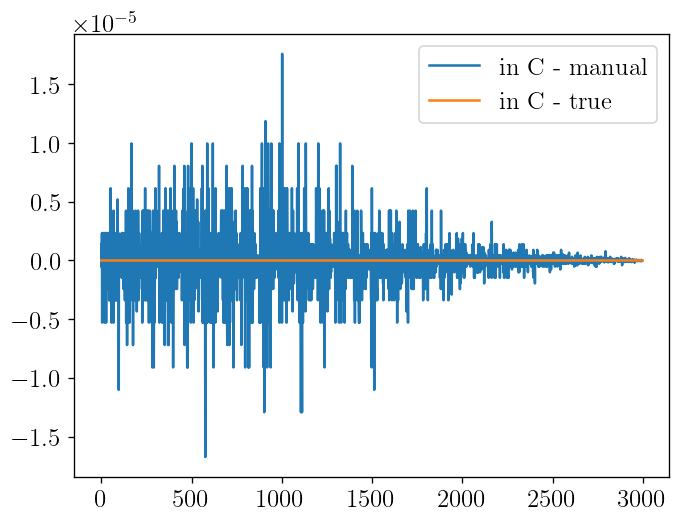

In [ ]:
plt.plot(derivs_C['s2_B'][0,0,:] - deriv_s2[0,0,:], label="in C - manual")
plt.plot(derivs_C['s2_B'][0,0,:] - np.ones(derivs_C['s2_B'].shape[-1])*P_eps[0]**2, label='in C - true')

# plt.hlines(P_eps[0]**2, 0,2996, colors="black")
# plt.plot(derivs_C['s2_B'][0,0,:], label='in C')
# plt.hlines(P_eps[0]**2, 0,2996, colors="black")
# plt.plot(deriv_s2_wedges[0,0,:], label='wedges')
plt.legend()
plt.show()

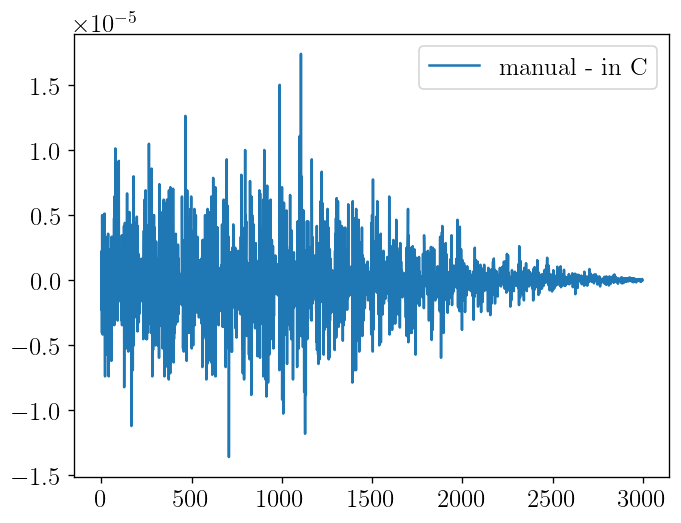

In [ ]:
plt.plot(deriv_s1[0,0,:] - derivs_C['s1_B'][0,0,:], label='manual - in C')
plt.legend()
plt.show()

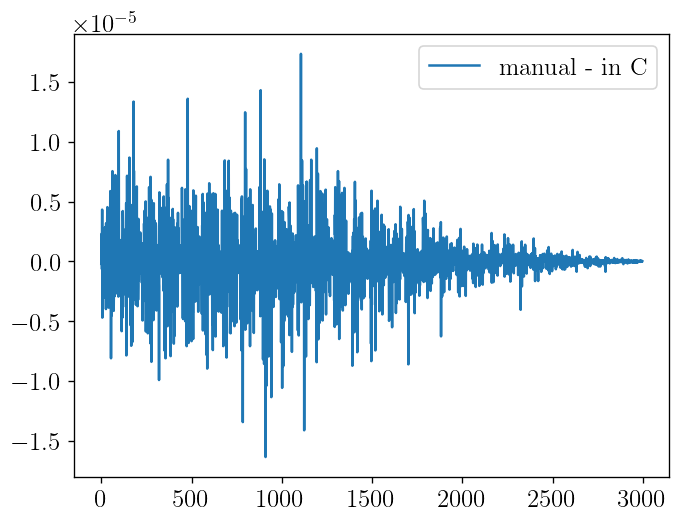

In [ ]:
plt.plot(deriv_s3[0,0,:] - derivs_C['s3_B'][0,0,:], label='manual - in C')
plt.legend()
plt.show()

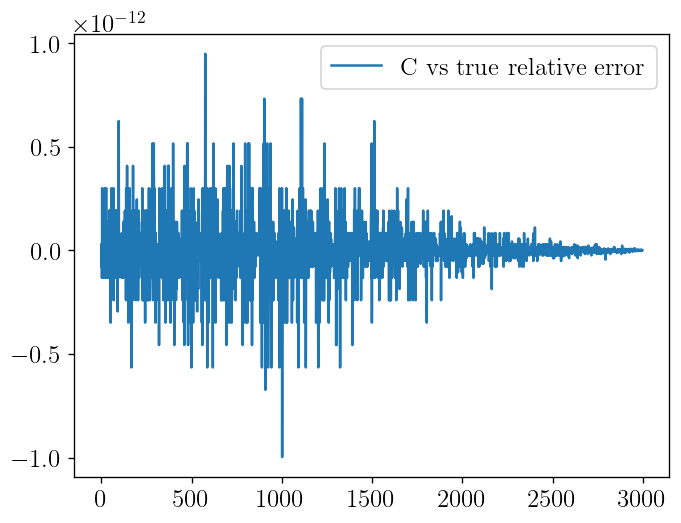

In [ ]:
plt.plot((deriv_s2[0,0,:] - np.ones(derivs_C['s2_B'].shape[-1])*P_eps[0]*P_eps[0])/(np.ones(derivs_C['s2_B'].shape[-1])*P_eps[0]*P_eps[0]), label='C vs true relative error')
# plt.plot(derivs_C['s2_B'][0,0,:] - deriv_s2[0,0,:], label='C - manual')
plt.legend()
plt.show()

### Compare bispec func output from Likelihood with directly from Classy

In [ ]:
# Define params for direct classy call
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.0219961,'omega_cdm':0.121203,'h':0.67,'A_s':2.0942702791129642e-9,'n_s':0.97,'z_reio':10., 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'tCl,pCl,lCl,mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0, 'nowiggle_pk_species':'total'})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()

# Make the AP factors
D_A_fid = 1663.9307801326001
H_fid = 0.00037966933846752485

h = LambdaCDM.h()
H = np.zeros(n_z, 'float64')
D_A = np.zeros(n_z, 'float64')
for i in range(n_z):
    D_A[i] = LambdaCDM.angular_distance(z[i]) # in Mpc
    H[i]   = LambdaCDM.Hubble(z[i])           # in (Mpc)^(-1)

#Alcock Pacinsky effect
q_orth = D_A/D_A_fid  # 1/f_orth  # alpha_perp
q_parr = H_fid/H                  # alpha_parallel

print(q_orth, q_parr)

AP_z = 1/(q_parr*q_orth**2)

use_IR_resum = 1

# galaxy bias:
b1 = np.array([1.3679])
b2 = np.array([-0.6209])
bG2 = np.array([-0.2283])
d1 = np.array([0.2])
d2 = np.array([0.1])
d3 = np.array([-1.1])
c1_FoG = np.array([0.1])

# read in remaining parameters from debug file from likelihood
with np.load('MontePython/montepython/data/F1_am_oneloop_debug.npz') as likelihood:
    B_l_likelihood = likelihood['B_l_am_0']
    P_d_likelihood = likelihood['P_d']
    z = likelihood['z']
    k_B = likelihood['k_B']
    P_shot_likelihood = likelihood['P_shot']

# get classy realization
B_l_classy, _ = LambdaCDM.bispectrum_and_derivs_treelevel_multipoles_AP_FoG(
                                                                            b1,
                                                                            b2,
                                                                            bG2,
                                                                            d1,
                                                                            d2,
                                                                            d3,
                                                                            P_shot_likelihood/AP_z,
                                                                            c1_FoG,
                                                                            k_B,
                                                                            z,
                                                                            2,
                                                                            q_orth,
                                                                            q_parr)

[1.] [1.]


(1, 2, 1654)


/tmp/zl884389/login23-1_2827349/ipykernel_1428105/3480878077.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[l].legend()


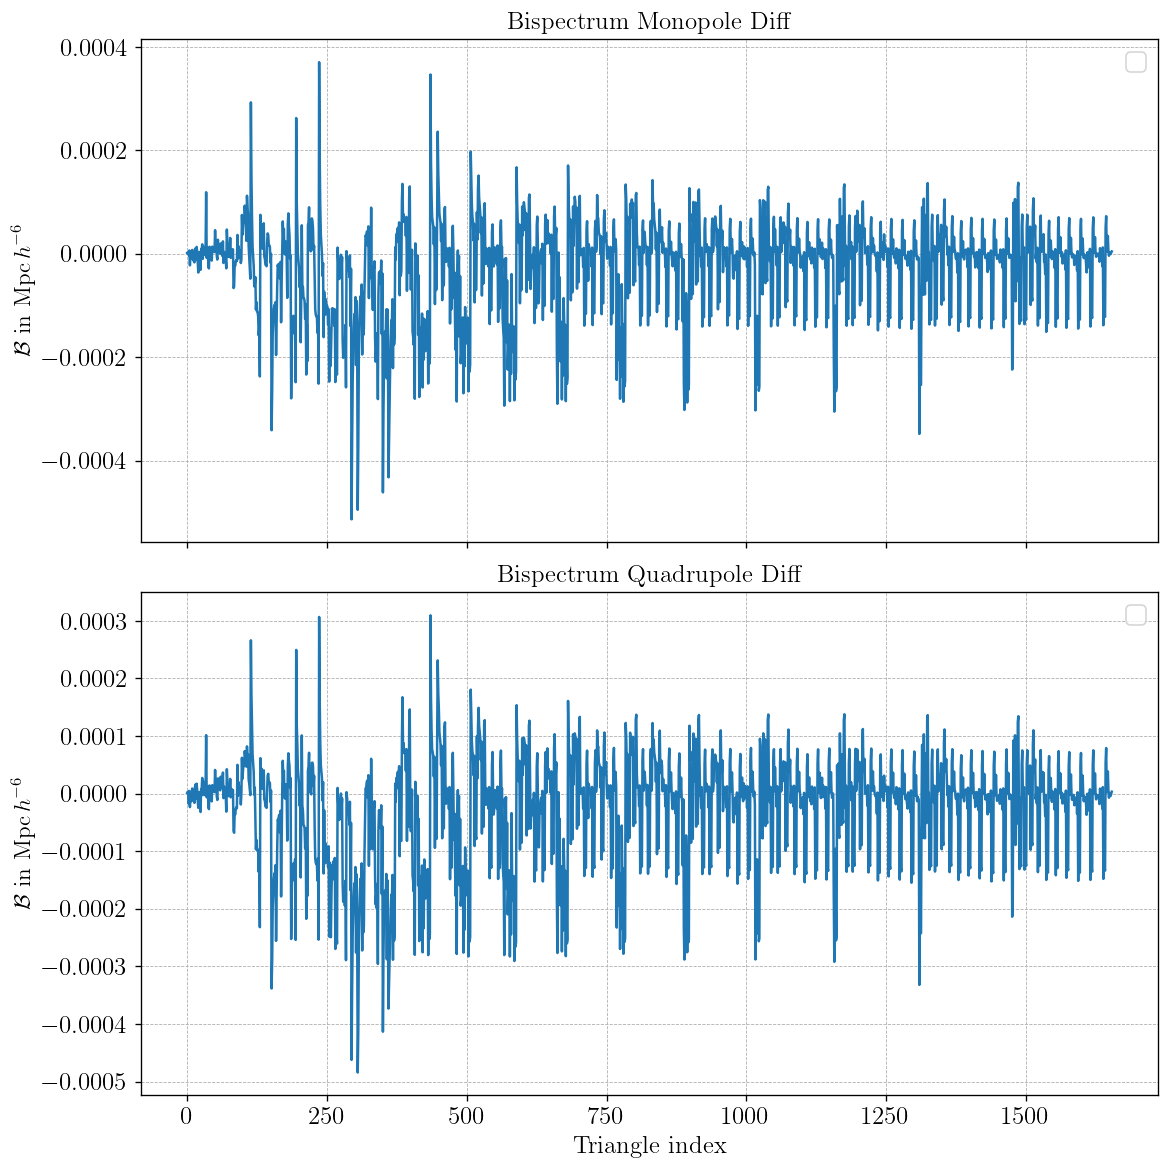

In [ ]:
print(B_l_classy.shape)
# Compare results
colors = plt.get_cmap("tab10").colors
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 10))
triangle_index = np.arange(k_B.shape[0])

# Plot realization with CLASS-OneLoop and data, aswell as their relative difference
for l in range(2):
    ax[l].plot(triangle_index, (B_l_likelihood[0,l,:] - B_l_classy[0,l,:])/B_l_classy[0,l,:], color=colors[0])
    ax[l].set_ylabel(r"$\mathcal{B}$ in $\mathrm{Mpc}\,h^{-6}$", fontsize=14)
    ax[l].grid(True, which='both', linestyle='--', linewidth=0.5)
    ax[l].legend()
ax[1].set_xlabel('Triangle index')
ax[0].set_title('Bispectrum Monopole Diff')
ax[1].set_title('Bispectrum Quadrupole Diff')

plt.tight_layout()
fig.subplots_adjust(wspace=0.25, hspace=0.1)
plt.show()

## Fynns comparison with Dennis

AttributeError: 'classy.Class' object has no attribute 'get_bk_lin_multipoles_configs'

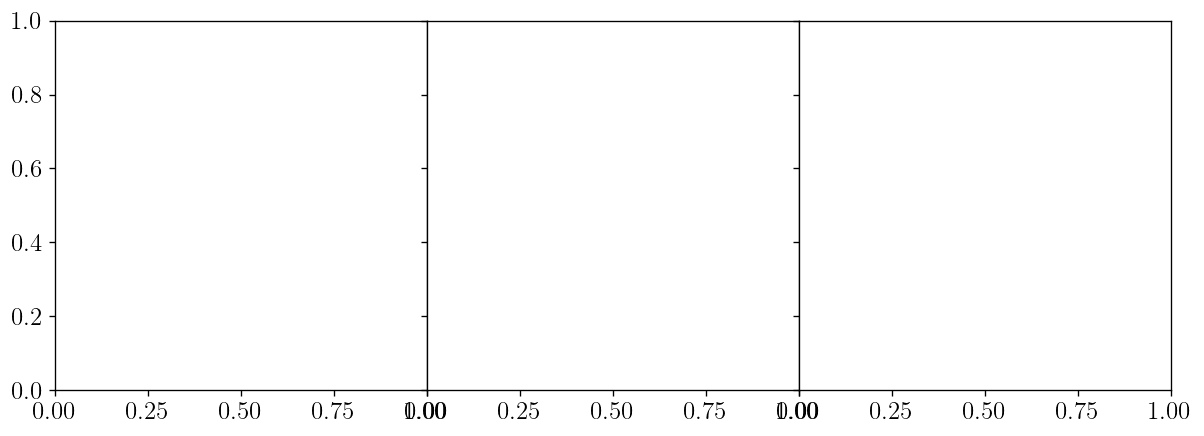

In [ ]:
triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in

# multipole l
l_s = [0, 2, 4]
labels = ["Monopole", "Quadrupole", "Hexadecapole"]
colors = ["tab:red", "tab:blue", "tab:green"]
ls = ["solid", "dashed", "dotted"]


#fig, ax = plt.subplots(3, 1, figsize=(7, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1], 'hspace': 0})

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True, gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0})

dx = 0.02
idx = 0
use_labels= True
for z_ in z:
    for type in triangle_types:
        for l_idx, l in enumerate(l_s):
            Bk_l = LambdaCDM.get_bk_lin_multipoles_configs(use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, type, k, l, z, k_size, z_size)
            Bk_l_1D = Bk_l[:, 0]
            plot_segments(ax[idx], k/h, Bk_l_1D*h**6, colors[l_idx], rf"{labels[l_idx]}", "solid", use_labels)
            #ax[idx].plot(k/h, Bk_l_1D*h**6)
        use_labels = False
        ax[idx].set_xscale("log")
        ax[idx].set_yscale("log")
        ax[idx].set_xlabel(rf"$k$ $\left[h/\mathrm{{Mpc}}\right]$")
        if type == "equi":
            ax[idx].set_ylabel(rf"$B_\ell(k_1, k_2, k_3, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for equilateral
            ax[idx].annotate("$k=k_1=k_2=k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Equilateral")
        elif type == "iso":
            #ax[idx].set_ylabel(rf"$B_\ell(k, 2k, 2k, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for isosceles
            ax[idx].annotate("$k=k_1=k_2=2k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Isosceles")
        elif type == "squeezed":
            #ax[idx].set_ylabel(rf"$B_\ell(k, k, k/10, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for squeezed
            ax[idx].annotate("$k=k_1=k_2=10k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Squeezed")

        ax[idx].set_ylim(1e4, 1.e10)
        ax[idx].set_xlim(8e-4, k_max)
        idx += 1
fig.legend(loc='center', bbox_to_anchor=(0.5, -0.005), ncol=3)

plt.tight_layout()
plt.savefig(f"bispectrum_multipoles_configs.pdf", bbox_inches='tight')
plt.show()






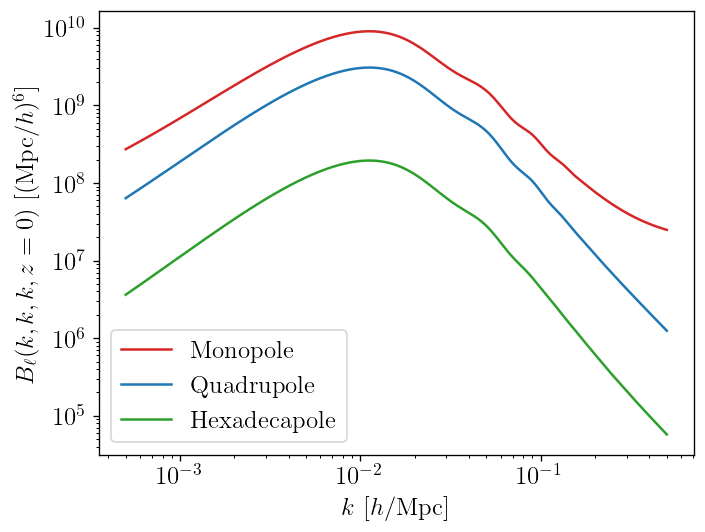

In [ ]:
triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in

# multipole l
l_s = [0, 2, 4]
labels = ["Monopole", "Quadrupole", "Hexadecapole"]
colors = ["tab:red", "tab:blue", "tab:green"]
ls = ["solid", "dashed", "dotted"]


#fig, ax = plt.subplots(3, 1, figsize=(7, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1], 'hspace': 0})


dx = 0.02
idx = 0
use_labels= True

for idx, l in enumerate(l_s):
    Bk_l = LambdaCDM.get_bk_lin_multipoles_configs(use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, "equi", k, l, z, k_size, z_size)
    Bk_l_1D = Bk_l[:, 0]
    plt.plot(k, Bk_l_1D, label=labels[idx], color=colors[idx])
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$B_\ell(k, k, k, z=0)$ $[(\mathrm{{Mpc}}/h)^6]$")
plt.xlabel(r"$k$ $[h/\mathrm{{Mpc}}]$")
plt.legend()
plt.savefig("bispectrum_single_showcase.pdf", bbox_inches='tight')